In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("brianleung2020/eeg-motor-movementimagery-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.87G/1.87G [00:30<00:00, 66.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/brianleung2020/eeg-motor-movementimagery-dataset/versions/1


In [2]:

!pip install mne
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 83.9 MB/s eta 0:00:00


In [3]:
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from pathlib import Path


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

path = kagglehub.dataset_download("brianleung2020/eeg-motor-movementimagery-dataset")
print(" Path to dataset:", path)

 Path to dataset: /root/.cache/kagglehub/datasets/brianleung2020/eeg-motor-movementimagery-dataset/versions/1


In [4]:

dataset_path = Path(path)
edf_files = list(dataset_path.rglob("*.edf"))

print(f"Znaleziono {len(edf_files)} plików EEG")
print(f"Przykładowy plik: {edf_files[0].name}")

Znaleziono 1526 plików EEG
Przykładowy plik: S092R08.edf


In [5]:

raw = mne.io.read_raw_edf(edf_files[0], preload=True, verbose=False)

print("Podstawowe informacje:")
print(f"Częstotliwość próbkowania: {raw.info['sfreq']} Hz")
print(f"Liczba kanałów: {len(raw.ch_names)}")
print(f"Kanały: {', '.join(raw.ch_names[:10])}...")
print(f"Czas trwania: {raw.times[-1]:.1f} sek ({raw.times[-1]/60:.1f} min)")

Podstawowe informacje:
Częstotliwość próbkowania: 128.0 Hz
Liczba kanałów: 64
Kanały: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.....
Czas trwania: 124.0 sek (2.1 min)


Using matplotlib as 2D backend.


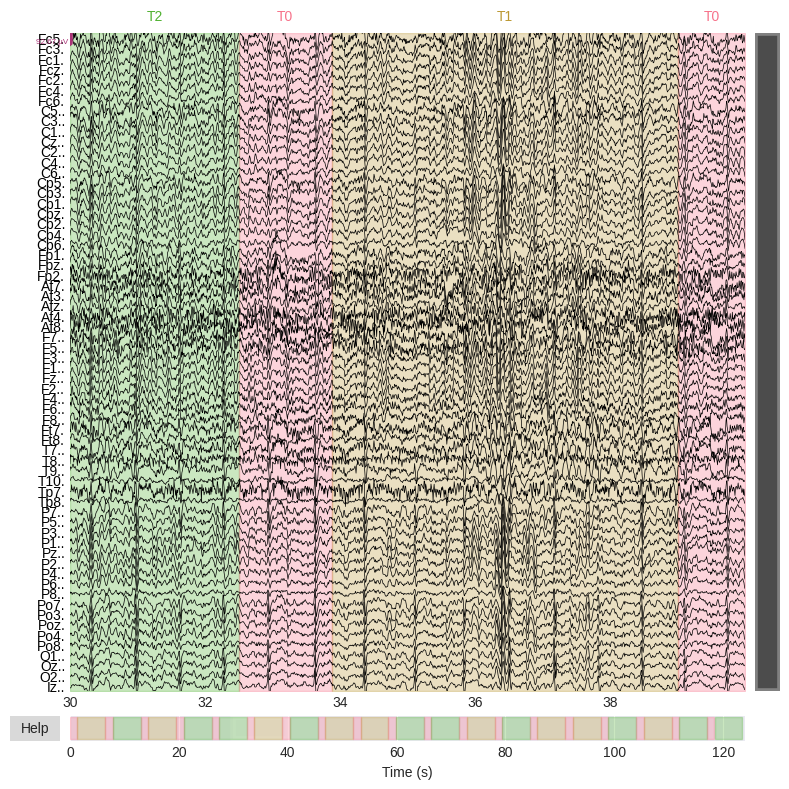

In [6]:

fig = raw.plot(duration=10, start=30, n_channels=len(raw.ch_names),
               scalings='auto', title='Surowy sygnał EEG (10 sekund)',
               show=False)
plt.tight_layout()
plt.show()

In [7]:


print("Analiza struktury danych")

if raw.annotations is not None and len(raw.annotations) > 0:
    print(f"Znaleziono {len(raw.annotations)} annotacji")
    print("\nPrzykładowe annotacje:")
    for i in range(min(10, len(raw.annotations))):
        print(f"  {raw.annotations[i]}")


    events, event_id = mne.events_from_annotations(raw, verbose=False)

    print(f"\nUtworzono {len(events)} eventów")
    print(f"Znalezione typy eventów: {event_id}")

else:
    print("Brak annotacji w tym pliku")
    print(f"Kanały: {raw.ch_names}")

    # Szukanie kanału ze znacznikami (często nazywa się 'STI' lub 'Status')
    stim_channels = [ch for ch in raw.ch_names if 'STI' in ch.upper() or 'STATUS' in ch.upper() or 'TRIGGER' in ch.upper()]

    if stim_channels:
        print(f"\nZnaleziono kanał ze znacznikami: {stim_channels[0]}")
        events = mne.find_events(raw, stim_channel=stim_channels[0], verbose=False)
        print(f"Utworzono {len(events)} eventów")

        # Ręczne mapowanie (na podstawie dokumentacji PhysioNet EEG Motor Movement/Imagery)
        event_id = {
            'T0': 1,
            'T1': 2,
            'T2': 3,
            'T3': 4,
            'T4': 5
        }
    else:
        print("\nNie znaleziono kanału ze znacznikami")
        print("Ten plik może nie zawierać eventów lub wymaga innego podejścia")


        print("\nTworzenie syntetycznych eventów dla demonstracji")
        n_events = 20
        event_samples = np.linspace(int(raw.info['sfreq']*10),
                                   int(len(raw.times) - raw.info['sfreq']*10),
                                   n_events, dtype=int)
        event_types = np.random.randint(1, 6, n_events)
        events = np.column_stack([event_samples, np.zeros(n_events, dtype=int), event_types])

        event_id = {
            'T0': 1,
            'T1': 2,
            'T2': 3,
            'T3': 4,
            'T4': 5
        }



event_dict = {
    1: 'Rest (T0)',
    2: 'Left Fist (T1)',
    3: 'Right Fist (T2)',
    4: 'Both Fists (T3)',
    5: 'Both Feet (T4)'
}


if isinstance(event_id, dict) and isinstance(list(event_id.keys())[0], str):
    event_dict_display = {v: k for k, v in event_id.items()}
else:
    event_dict_display = event_dict

print("\n Zadania mnoter imagery")

unique_events = np.unique(events[:, 2])
for event_id_num in unique_events:
    count = np.sum(events[:, 2] == event_id_num)
    name = event_dict_display.get(event_id_num, event_dict.get(event_id_num, f'Unknown {event_id_num}'))
    print(f"{name}: {count} prób")

Analiza struktury danych
Znaleziono 38 annotacji

Przykładowe annotacje:
  OrderedDict({'onset': np.float64(0.0), 'duration': np.float64(1.375), 'description': np.str_('T0'), 'orig_time': datetime.datetime(2009, 8, 12, 16, 15, tzinfo=datetime.timezone.utc), 'extras': {}})
  OrderedDict({'onset': np.float64(1.375), 'duration': np.float64(5.125), 'description': np.str_('T1'), 'orig_time': datetime.datetime(2009, 8, 12, 16, 15, tzinfo=datetime.timezone.utc), 'extras': {}})
  OrderedDict({'onset': np.float64(6.5), 'duration': np.float64(1.375), 'description': np.str_('T0'), 'orig_time': datetime.datetime(2009, 8, 12, 16, 15, tzinfo=datetime.timezone.utc), 'extras': {}})
  OrderedDict({'onset': np.float64(7.875), 'duration': np.float64(5.125), 'description': np.str_('T2'), 'orig_time': datetime.datetime(2009, 8, 12, 16, 15, tzinfo=datetime.timezone.utc), 'extras': {}})
  OrderedDict({'onset': np.float64(13.0), 'duration': np.float64(1.375), 'description': np.str_('T0'), 'orig_time': datetim

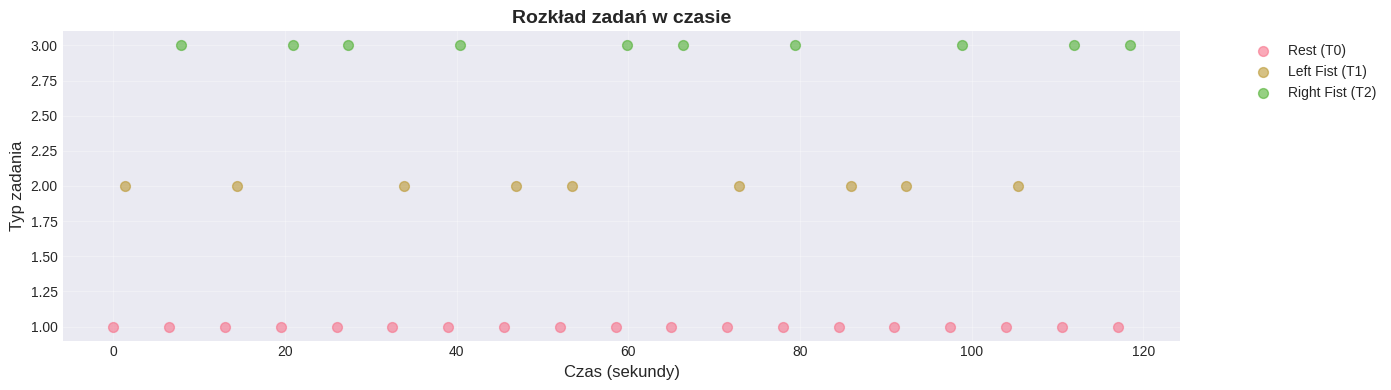

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))

for event_id in unique_events:
    mask = events[:, 2] == event_id
    times = events[mask, 0] / raw.info['sfreq']
    ax.scatter(times, [event_id] * len(times),
               label=event_dict.get(event_id, f'Event {event_id}'),
               alpha=0.6, s=50)

ax.set_xlabel('Czas (sekundy)', fontsize=12)
ax.set_ylabel('Typ zadania', fontsize=12)
ax.set_title('Rozkład zadań w czasie', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

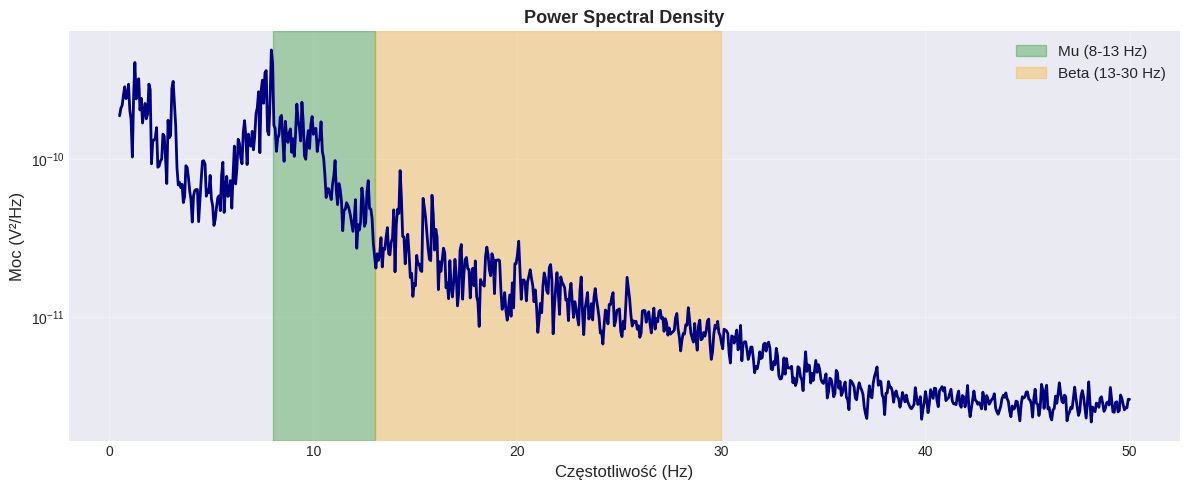

In [9]:

spectrum = raw.compute_psd(fmin=0.5, fmax=50, n_fft=2048, verbose=False)
psds, freqs = spectrum.get_data(return_freqs=True)
psds_mean = psds.mean(axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogy(freqs, psds_mean, linewidth=2, color='navy')

bands = {
    'Mu (8-13 Hz)': (8, 13, 'green'),
    'Beta (13-30 Hz)': (13, 30, 'orange')
}

for band_name, (low, high, color) in bands.items():
    ax.axvspan(low, high, alpha=0.3, color=color, label=band_name)

ax.set_xlabel('Częstotliwość (Hz)', fontsize=12)
ax.set_ylabel('Moc (V²/Hz)', fontsize=12)
ax.set_title('Power Spectral Density',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [10]:

tmin, tmax = -1.0, 4.0
event_id = {v: k for k, v in event_dict.items() if k in unique_events}

epochs = mne.Epochs(raw, events, event_id=event_id, tmin=tmin, tmax=tmax,
                    baseline=(tmin, 0), preload=True, verbose=False)

print("Epoki")
print(f"Utworzono {len(epochs)} epok")
print(f"Długość epoki: {tmax - tmin} sekund\n")

for task_name in event_id.keys():
    n = len(epochs[task_name])
    print(f"{task_name}: {n} epok")

Epoki
Utworzono 37 epok
Długość epoki: 5.0 sekund

Rest (T0): 18 epok
Left Fist (T1): 9 epok
Right Fist (T2): 10 epok


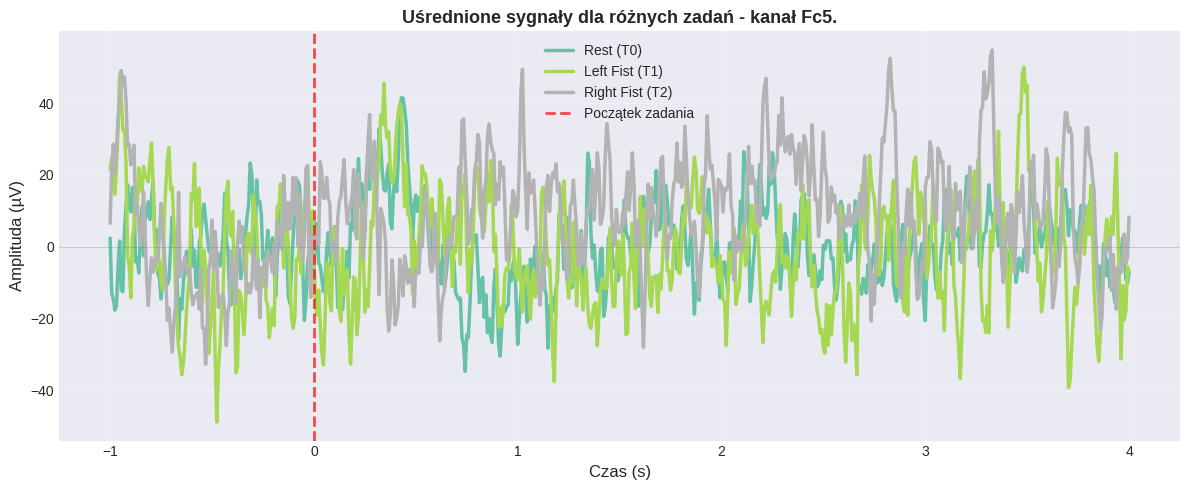

In [11]:

fig, ax = plt.subplots(figsize=(12, 5))

colors = plt.cm.Set2(np.linspace(0, 1, len(event_id)))


channel = 'C3' if 'C3' in raw.ch_names else raw.ch_names[0]

for (task_name, task_id), color in zip(event_id.items(), colors):
    evoked = epochs[task_name].average()
    if channel in evoked.ch_names:
        ch_idx = evoked.ch_names.index(channel)
        data = evoked.data[ch_idx, :] * 1e6
        ax.plot(evoked.times, data, label=task_name, linewidth=2.5, color=color)

ax.axvline(x=0, color='red', linestyle='--', linewidth=2,
           alpha=0.7, label='Początek zadania')
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
ax.set_xlabel('Czas (s)', fontsize=12)
ax.set_ylabel('Amplituda (µV)', fontsize=12)
ax.set_title(f'Uśrednione sygnały dla różnych zadań - kanał {channel}',
             fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


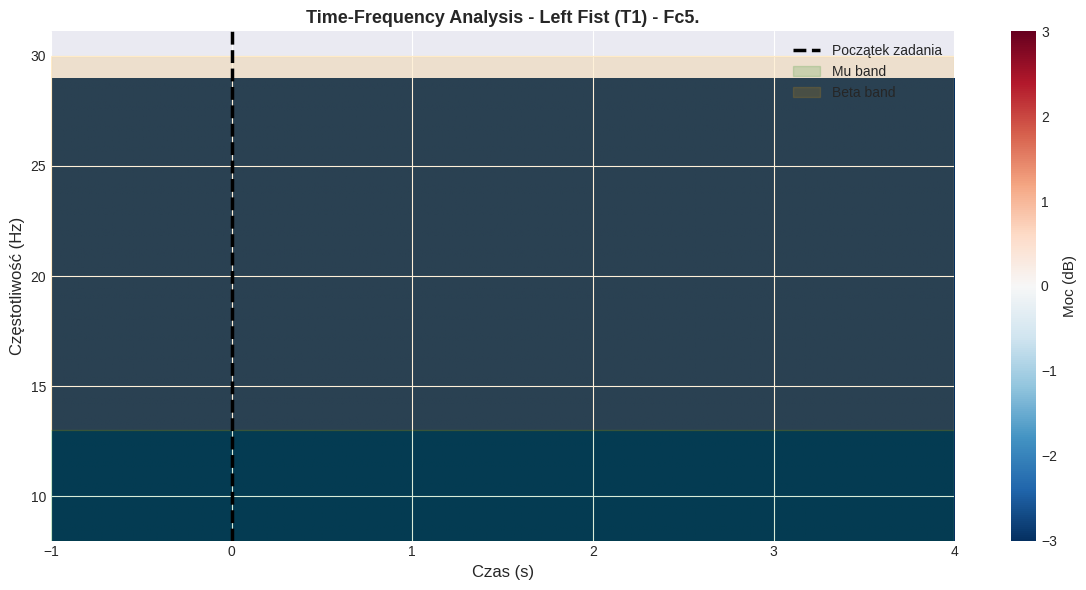

In [12]:

freqs_tfr = np.arange(8, 30, 1)
n_cycles = freqs_tfr / 2.


task_to_analyze = list(event_id.keys())[1] if len(event_id) > 1 else list(event_id.keys())[0]

power = mne.time_frequency.tfr_morlet(epochs[task_to_analyze], freqs=freqs_tfr,
                                      n_cycles=n_cycles, return_itc=False,
                                      average=True, verbose=False)

channel_tfr = 'C3' if 'C3' in power.ch_names else power.ch_names[0]
ch_idx = power.ch_names.index(channel_tfr)


fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(10 * np.log10(power.data[ch_idx, :, :]),
               extent=[power.times[0], power.times[-1], freqs_tfr[0], freqs_tfr[-1]],
               aspect='auto', origin='lower', cmap='RdBu_r', vmin=-3, vmax=3)

ax.axvline(x=0, color='black', linestyle='--', linewidth=2.5,
           label='Początek zadania')
ax.axhspan(8, 13, alpha=0.15, color='green', label='Mu band')
ax.axhspan(13, 30, alpha=0.15, color='orange', label='Beta band')

ax.set_xlabel('Czas (s)', fontsize=12)
ax.set_ylabel('Częstotliwość (Hz)', fontsize=12)
ax.set_title(f'Time-Frequency Analysis - {task_to_analyze} - {channel_tfr}',
             fontsize=13, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Moc (dB)', fontsize=11)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [13]:
# --- Rozszerzona EDA: analiza na WSZYSTKICH subjectach ---
# Poniżej: ładowanie danych z wielu osób, porównanie eventów,
# analiza kanałów, SNR, CSP, topografia

In [14]:
import re
from collections import defaultdict
from mne.decoding import CSP
from scipy.stats import pearsonr

# --- Mapowanie runów do typów zadań ---
# PhysioNet Motor Imagery Dataset:
#   R01: baseline eyes open, R02: baseline eyes closed
#   R03,R07,R11: ruch - T1=lewa pięść, T2=prawa pięść
#   R04,R08,R12: ruch - T1=obie pięści, T2=obie stopy
#   R05,R09,R13: wyobraźnia - T1=lewa pięść, T2=prawa pięść
#   R06,R10,R14: wyobraźnia - T1=obie pięści, T2=obie stopy

MOTOR_EXEC_LR = [3, 7, 11]
MOTOR_EXEC_FF = [4, 8, 12]
IMAGERY_LR    = [5, 9, 13]
IMAGERY_FF    = [6, 10, 14]

ALL_TASK_RUNS = MOTOR_EXEC_LR + MOTOR_EXEC_FF + IMAGERY_LR + IMAGERY_FF

def parse_filename(filepath):
    """Wyciąga numer subjecta i numer runu z nazwy pliku."""
    name = filepath.stem
    match = re.match(r'S(\d+)R(\d+)', name)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None, None

def get_run_event_mapping(run_num):
    """Zwraca mapowanie eventów T1/T2 na konkretne klasy w zależności od runu."""
    if run_num in MOTOR_EXEC_LR or run_num in IMAGERY_LR:
        return {'T1': 'Left Fist', 'T2': 'Right Fist'}
    elif run_num in MOTOR_EXEC_FF or run_num in IMAGERY_FF:
        return {'T1': 'Both Fists', 'T2': 'Both Feet'}
    return {}

def clean_channel_names(raw_obj):
    """Czyści nazwy kanałów (usuwa kropki, normalizuje wielkość liter) i ustawia montaż."""
    # 1. Usuń kropki z końca nazw kanałów
    mapping = {}
    for ch in raw_obj.ch_names:
        clean = ch.rstrip('.').strip()
        if clean != ch:
            mapping[ch] = clean
    if mapping:
        raw_obj.rename_channels(mapping)

    # 2. Dopasuj wielkość liter do montażu (case-insensitive matching)
    montage = mne.channels.make_standard_montage('standard_1005')
    montage_ch_lower = {ch.lower(): ch for ch in montage.ch_names}
    case_mapping = {}
    for ch in raw_obj.ch_names:
        canonical = montage_ch_lower.get(ch.lower())
        if canonical is not None and canonical != ch:
            case_mapping[ch] = canonical
    if case_mapping:
        raw_obj.rename_channels(case_mapping)

    # 3. Przypisz montaż
    try:
        raw_obj.set_montage(montage, on_missing='ignore')
    except Exception:
        pass
    return raw_obj

# --- Ładowanie danych z wielu subjectów ---
N_SUBJECTS = 10  # Zmień na więcej, np. 109, jeśli masz dużo RAM
TMIN, TMAX = -1.0, 4.0

subjects_files = defaultdict(list)
for f in edf_files:
    subj, run = parse_filename(f)
    if subj is not None and run in ALL_TASK_RUNS:
        subjects_files[subj].append((run, f))

subject_ids = sorted(subjects_files.keys())[:N_SUBJECTS]

all_epochs = []
all_labels = []
epoch_metadata = []

print(f"Ładowanie danych z {len(subject_ids)} subjectów...")

for subj_id in subject_ids:
    files = subjects_files[subj_id]
    for run_num, fpath in sorted(files):
        try:
            raw_subj = mne.io.read_raw_edf(fpath, preload=True, verbose=False)
            raw_subj = clean_channel_names(raw_subj)

            if raw_subj.annotations is None or len(raw_subj.annotations) == 0:
                continue

            ev, ev_id = mne.events_from_annotations(raw_subj, verbose=False)
            mapping = get_run_event_mapping(run_num)
            if not mapping:
                continue

            new_event_id = {}
            for annot_key, annot_val in ev_id.items():
                if annot_key in mapping:
                    new_event_id[mapping[annot_key]] = annot_val

            if not new_event_id:
                continue

            epochs_subj = mne.Epochs(
                raw_subj, ev, event_id=new_event_id,
                tmin=TMIN, tmax=TMAX, baseline=(TMIN, 0),
                preload=True, verbose=False
            )
            all_epochs.append(epochs_subj)

            for label in epochs_subj.events[:, 2]:
                inv_map = {v: k for k, v in new_event_id.items()}
                all_labels.append(inv_map.get(label, 'Unknown'))
                epoch_metadata.append({
                    'subject': subj_id,
                    'run': run_num,
                    'label': inv_map.get(label, 'Unknown')
                })

        except Exception as e:
            pass

print(f"Załadowano {len(all_epochs)} sesji z {len(subject_ids)} subjectów")
print(f"Łączna liczba epok: {len(all_labels)}")

# Połącz wszystkie epoki w jedną strukturę
combined_epochs = mne.concatenate_epochs(all_epochs)
print(f"\nPołączone epoki: {combined_epochs}")
print(f"Dostępne klasy: {list(combined_epochs.event_id.keys())}")

Ładowanie danych z 10 subjectów...
Załadowano 120 sesji z 10 subjectów
Łączna liczba epok: 1800


/tmp/ipython-input-1345235605.py:130: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  combined_epochs = mne.concatenate_epochs(all_epochs)


Not setting metadata
1800 matching events found
Applying baseline correction (mode: mean)

Połączone epoki: <EpochsArray | 1800 events (all good), -1 – 4 s (baseline -1 – 0 s), ~704.1 MiB, data loaded,
 'Left Fist': 903
 'Right Fist': 897
 'Both Fists': 903
 'Both Feet': 897>
Dostępne klasy: ['Left Fist', 'Right Fist', 'Both Fists', 'Both Feet']


=== Rozkład klas (eventów) na wszystkich subjectach ===

label
Both Fists    454
Right Fist    451
Left Fist     449
Both Feet     446
Name: count, dtype: int64



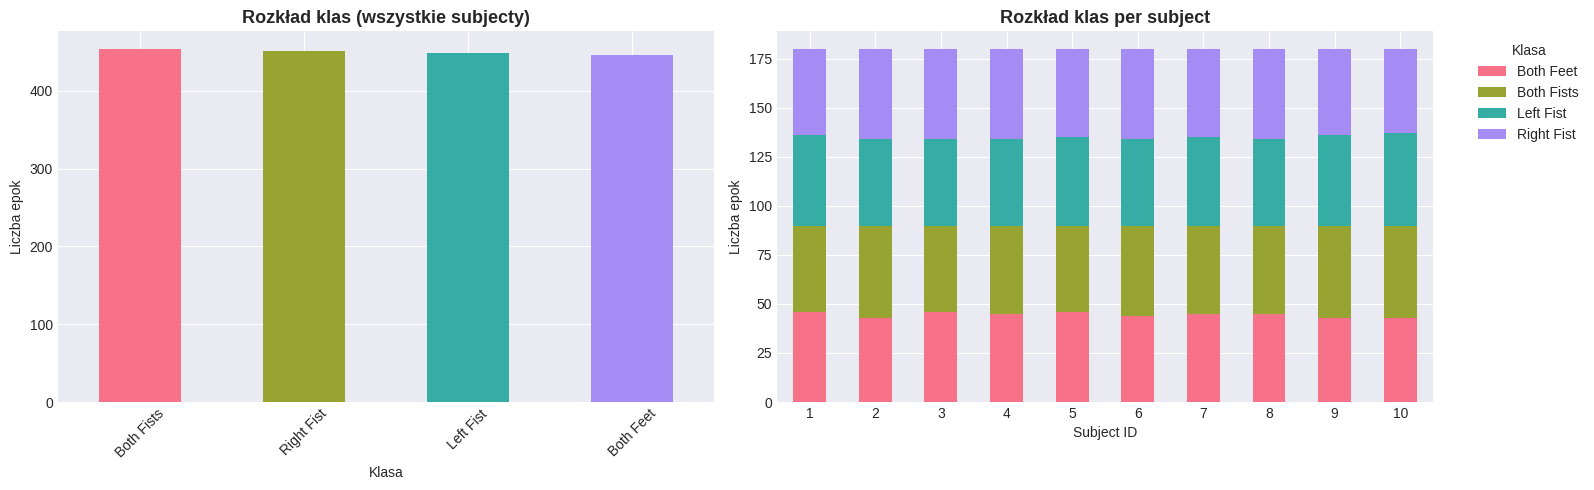


=== Podział subjectów na grupy (parzyste/nieparzyste ID) ===
(W tym datasecie nie ma metadanych o płci, więc używamy podziału na grupy)
label                  Both Feet  Both Fists  Left Fist  Right Fist
group                                                              
Grupa A (parzyste)           220         230        223         227
Grupa B (nieparzyste)        226         224        226         224


In [15]:
# --- Statystyki eventów na wszystkich subjectach ---

import pandas as pd

df_meta = pd.DataFrame(epoch_metadata)

print("=== Rozkład klas (eventów) na wszystkich subjectach ===\n")
class_counts = df_meta['label'].value_counts()
print(class_counts)
print()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

class_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette("husl", len(class_counts)))
axes[0].set_title('Rozkład klas (wszystkie subjecty)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Liczba epok')
axes[0].set_xlabel('Klasa')
axes[0].tick_params(axis='x', rotation=45)

subj_class = df_meta.groupby(['subject', 'label']).size().unstack(fill_value=0)
subj_class.plot(kind='bar', stacked=True, ax=axes[1],
                color=sns.color_palette("husl", len(class_counts)))
axes[1].set_title('Rozkład klas per subject', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Liczba epok')
axes[1].set_xlabel('Subject ID')
axes[1].legend(title='Klasa', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Podział na grupy subjectów (np. parzyste/nieparzyste jako proxy dla braku danych o płci)
print("\n=== Podział subjectów na grupy (parzyste/nieparzyste ID) ===")
print("(W tym datasecie nie ma metadanych o płci, więc używamy podziału na grupy)")
df_meta['group'] = df_meta['subject'].apply(lambda x: 'Grupa A (parzyste)' if x % 2 == 0 else 'Grupa B (nieparzyste)')

group_counts = df_meta.groupby(['group', 'label']).size().unstack(fill_value=0)
print(group_counts)

Dostępne klasy do porównania: ['Left Fist', 'Right Fist', 'Both Fists', 'Both Feet']



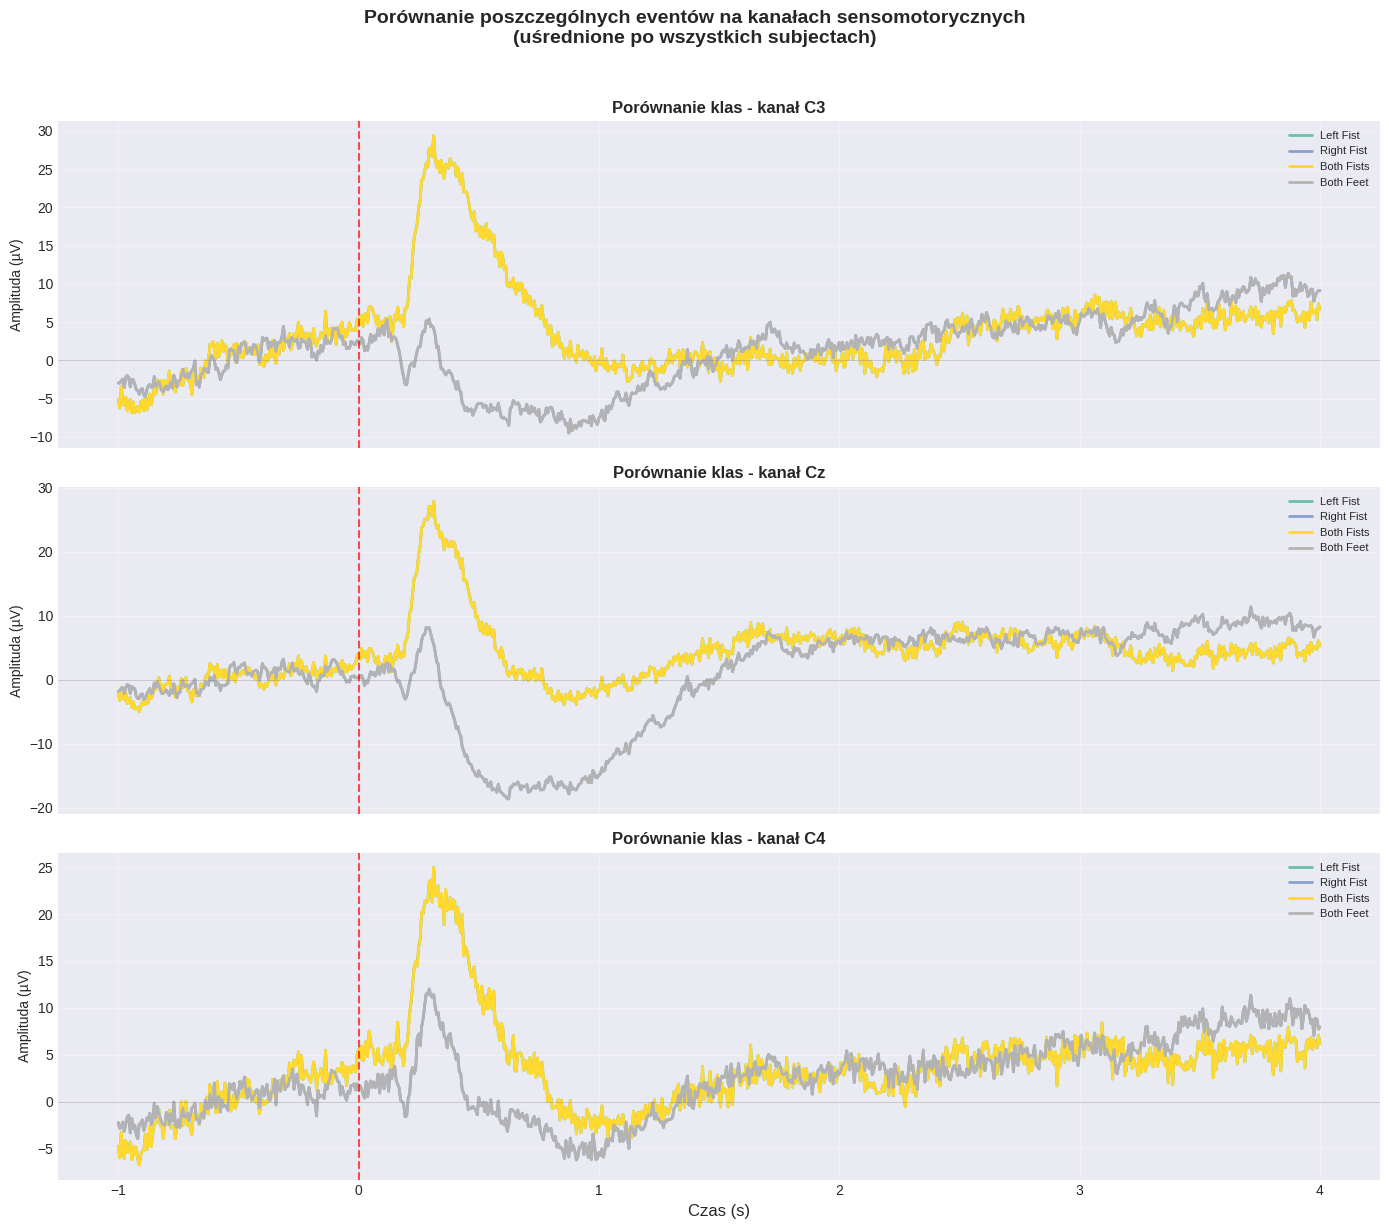

In [16]:
# --- Porównanie poszczególnych eventów (ręka, noga, etc.) ---
# Wyciągamy uśrednione sygnały (evoked) dla każdej klasy osobno i porównujemy

available_classes = list(combined_epochs.event_id.keys())
print(f"Dostępne klasy do porównania: {available_classes}\n")

# Kluczowe kanały dla motor imagery (okolica sensomotoryczna)
motor_channels = ['C3', 'Cz', 'C4', 'Fc3', 'Fc4', 'Cp3', 'Cp4']
available_motor_ch = [ch for ch in motor_channels if ch in combined_epochs.ch_names]

if not available_motor_ch:
    available_motor_ch = combined_epochs.ch_names[:4]

n_ch = len(available_motor_ch)
n_classes = len(available_classes)
colors = plt.cm.Set2(np.linspace(0, 1, n_classes))

fig, axes = plt.subplots(n_ch, 1, figsize=(14, 4 * n_ch), sharex=True)
if n_ch == 1:
    axes = [axes]

for ch_idx, ch_name in enumerate(available_motor_ch):
    ax = axes[ch_idx]
    for cls_idx, cls_name in enumerate(available_classes):
        evoked = combined_epochs[cls_name].average()
        if ch_name in evoked.ch_names:
            data_idx = evoked.ch_names.index(ch_name)
            data = evoked.data[data_idx, :] * 1e6
            ax.plot(evoked.times, data, label=cls_name,
                    linewidth=2, color=colors[cls_idx])

    ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.set_ylabel('Amplituda (µV)', fontsize=10)
    ax.set_title(f'Porównanie klas - kanał {ch_name}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Czas (s)', fontsize=12)
plt.suptitle('Porównanie poszczególnych eventów na kanałach sensomotorycznych\n(uśrednione po wszystkich subjectach)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

=== Analiza mocy per kanał per klasa ===

Obliczanie mocy w pasmach Mu (8-13 Hz) i Beta (13-30 Hz)...



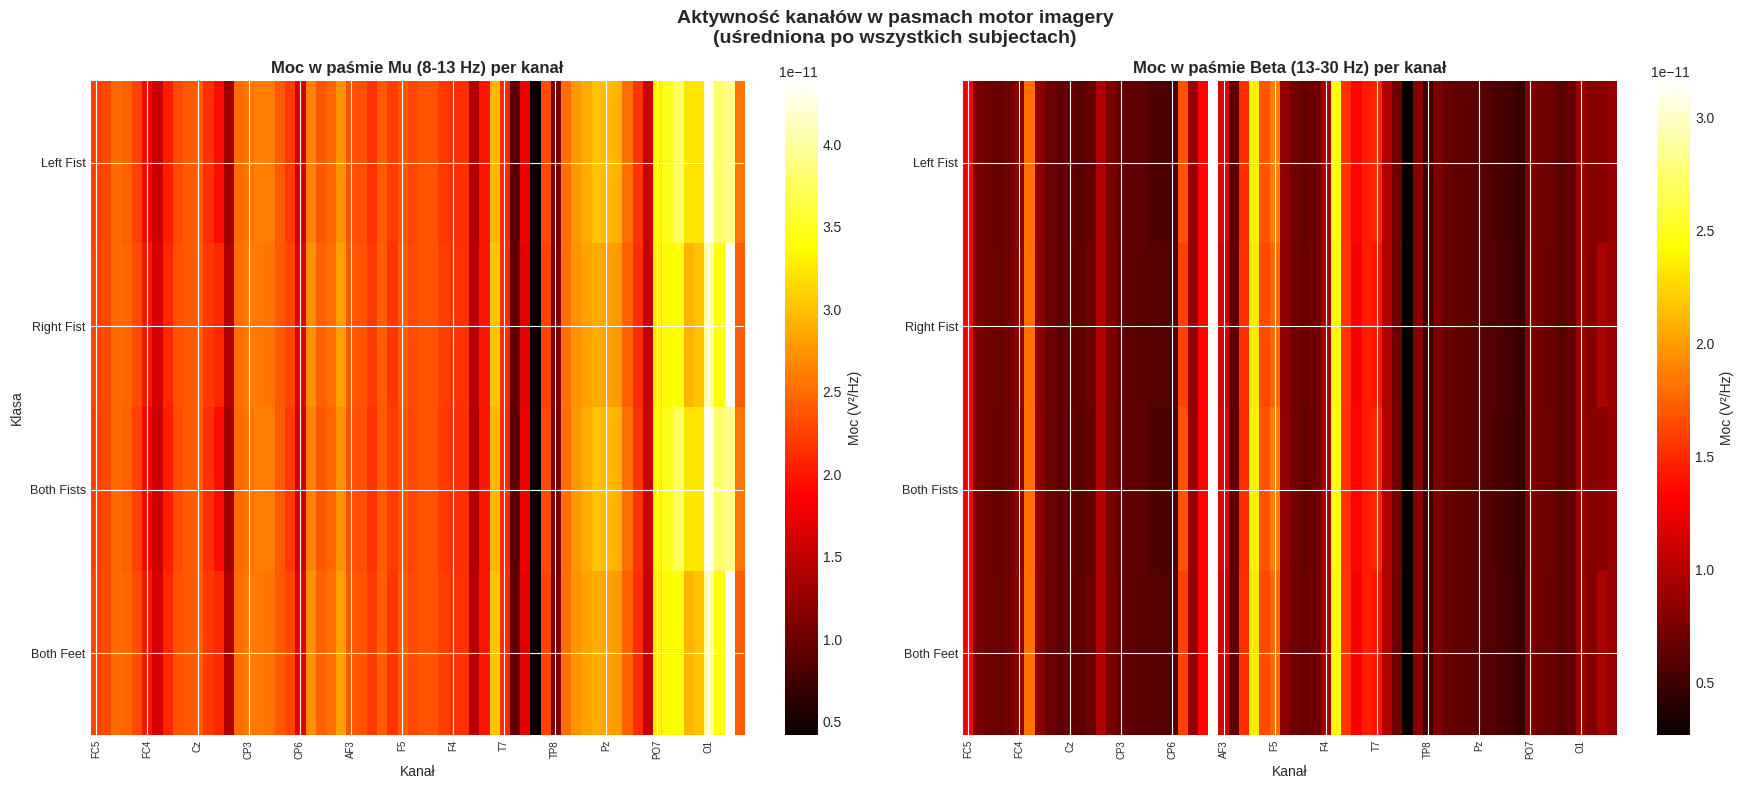


=== Top 10 najbardziej dyskryminacyjnych kanałów ===
(największa wariancja mocy Mu między klasami)

  1. O2       - wariancja Mu: 5.2131e-24
  2. Oz       - wariancja Mu: 3.8608e-24
  3. POz      - wariancja Mu: 2.9976e-24
  4. O1       - wariancja Mu: 2.4751e-24
  5. PO4      - wariancja Mu: 2.1319e-24
  6. PO8      - wariancja Mu: 1.0168e-24
  7. C4       - wariancja Mu: 7.3281e-25
  8. Iz       - wariancja Mu: 6.2510e-25
  9. Pz       - wariancja Mu: 5.4408e-25
  10. P2       - wariancja Mu: 5.0725e-25


In [17]:
# --- Analiza kanałów: który kanał daje największą aktywność per klasa ---
# Obliczamy średnią moc w paśmie Mu (8-13 Hz) i Beta (13-30 Hz) per kanał per klasa

from scipy.signal import welch

def compute_band_power(data, sfreq, band):
    """Oblicza średnią moc w podanym paśmie częstotliwości."""
    fmin, fmax = band
    freqs, psd = welch(data, fs=sfreq, nperseg=min(256, data.shape[-1]))
    mask = (freqs >= fmin) & (freqs <= fmax)
    return psd[..., mask].mean(axis=-1)

mu_band = (8, 13)
beta_band = (13, 30)
sfreq = combined_epochs.info['sfreq']
ch_names = combined_epochs.ch_names

print("=== Analiza mocy per kanał per klasa ===\n")
print("Obliczanie mocy w pasmach Mu (8-13 Hz) i Beta (13-30 Hz)...\n")

results = {}
for cls_name in available_classes:
    cls_data = combined_epochs[cls_name].get_data()
    mu_power = compute_band_power(cls_data, sfreq, mu_band)
    beta_power = compute_band_power(cls_data, sfreq, beta_band)
    results[cls_name] = {
        'mu': mu_power.mean(axis=0),
        'beta': beta_power.mean(axis=0)
    }

# Heatmapa: moc Mu per kanał per klasa
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

mu_matrix = np.array([results[cls]['mu'] for cls in available_classes])
beta_matrix = np.array([results[cls]['beta'] for cls in available_classes])

im1 = axes[0].imshow(mu_matrix, aspect='auto', cmap='hot')
axes[0].set_yticks(range(len(available_classes)))
axes[0].set_yticklabels(available_classes, fontsize=9)
axes[0].set_xticks(range(0, len(ch_names), 5))
axes[0].set_xticklabels([ch_names[i] for i in range(0, len(ch_names), 5)],
                        rotation=90, fontsize=7)
axes[0].set_title('Moc w paśmie Mu (8-13 Hz) per kanał', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kanał')
axes[0].set_ylabel('Klasa')
plt.colorbar(im1, ax=axes[0], label='Moc (V²/Hz)')

im2 = axes[1].imshow(beta_matrix, aspect='auto', cmap='hot')
axes[1].set_yticks(range(len(available_classes)))
axes[1].set_yticklabels(available_classes, fontsize=9)
axes[1].set_xticks(range(0, len(ch_names), 5))
axes[1].set_xticklabels([ch_names[i] for i in range(0, len(ch_names), 5)],
                        rotation=90, fontsize=7)
axes[1].set_title('Moc w paśmie Beta (13-30 Hz) per kanał', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kanał')
plt.colorbar(im2, ax=axes[1], label='Moc (V²/Hz)')

plt.suptitle('Aktywność kanałów w pasmach motor imagery\n(uśredniona po wszystkich subjectach)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top 10 kanałów z największą różnicą między klasami (dyskryminacyjne)
print("\n=== Top 10 najbardziej dyskryminacyjnych kanałów ===")
print("(największa wariancja mocy Mu między klasami)\n")

mu_variance = mu_matrix.var(axis=0)
top_ch_indices = np.argsort(mu_variance)[::-1][:10]
for rank, idx in enumerate(top_ch_indices, 1):
    print(f"  {rank}. {ch_names[idx]:8s} - wariancja Mu: {mu_variance[idx]:.4e}")

=== SNR (Signal-to-Noise Ratio) per klasa ===



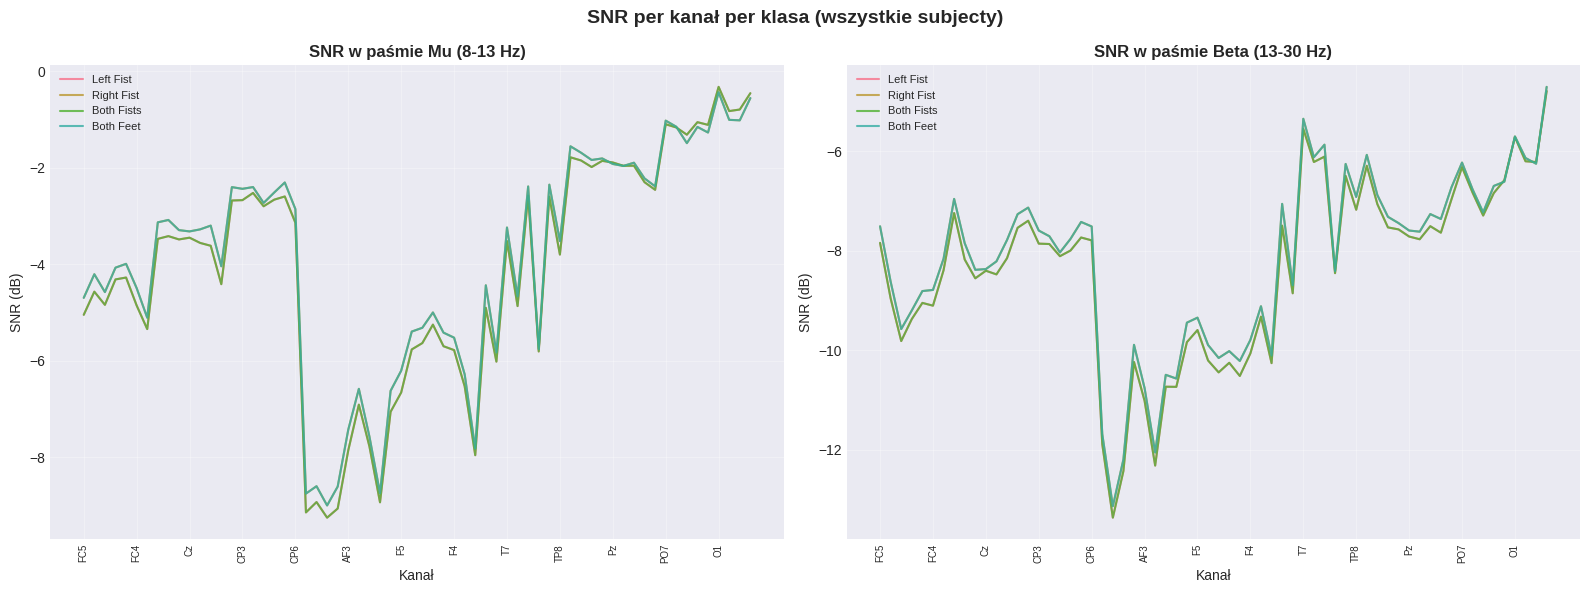


Średni SNR per klasa (uśredniony po wszystkich kanałach):
  Left Fist       - Mu SNR: -4.10 dB, Beta SNR: -8.38 dB
  Right Fist      - Mu SNR: -3.90 dB, Beta SNR: -8.17 dB
  Both Fists      - Mu SNR: -4.10 dB, Beta SNR: -8.38 dB
  Both Feet       - Mu SNR: -3.90 dB, Beta SNR: -8.17 dB


In [18]:
# --- Obliczanie SNR (Signal-to-Noise Ratio) ---
# SNR = moc sygnału / moc szumu
# Sygnał: pasma Mu (8-13 Hz) i Beta (13-30 Hz)
# Szum: reszta pasma (np. 1-8 Hz + 30-50 Hz)

def compute_snr(data, sfreq, signal_band, noise_bands):
    """Oblicza SNR w dB dla podanego pasma sygnału vs pasma szumu."""
    freqs, psd = welch(data, fs=sfreq, nperseg=min(256, data.shape[-1]))

    sig_mask = (freqs >= signal_band[0]) & (freqs <= signal_band[1])
    signal_power = psd[..., sig_mask].mean(axis=-1)

    noise_power = np.zeros_like(signal_power)
    for nb in noise_bands:
        n_mask = (freqs >= nb[0]) & (freqs <= nb[1])
        noise_power += psd[..., n_mask].mean(axis=-1)
    noise_power /= len(noise_bands)

    snr = 10 * np.log10(signal_power / (noise_power + 1e-30))
    return snr

signal_band_mu = (8, 13)
signal_band_beta = (13, 30)
noise_bands = [(1, 7), (31, 50)]

print("=== SNR (Signal-to-Noise Ratio) per klasa ===\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for band_idx, (band_name, sig_band) in enumerate([('Mu (8-13 Hz)', signal_band_mu),
                                                     ('Beta (13-30 Hz)', signal_band_beta)]):
    ax = axes[band_idx]
    snr_per_class = {}

    for cls_name in available_classes:
        cls_data = combined_epochs[cls_name].get_data()
        snr = compute_snr(cls_data, sfreq, sig_band, noise_bands)
        snr_mean = snr.mean(axis=0)
        snr_per_class[cls_name] = snr_mean

    snr_matrix = np.array([snr_per_class[cls] for cls in available_classes])

    for cls_idx, cls_name in enumerate(available_classes):
        ax.plot(range(len(ch_names)), snr_per_class[cls_name],
                label=cls_name, linewidth=1.5, alpha=0.8)

    ax.set_xticks(range(0, len(ch_names), 5))
    ax.set_xticklabels([ch_names[i] for i in range(0, len(ch_names), 5)],
                        rotation=90, fontsize=7)
    ax.set_title(f'SNR w paśmie {band_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Kanał')
    ax.set_ylabel('SNR (dB)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('SNR per kanał per klasa (wszystkie subjecty)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Podsumowanie SNR per klasa (uśrednione po kanałach)
print("\nŚredni SNR per klasa (uśredniony po wszystkich kanałach):")
for cls_name in available_classes:
    cls_data = combined_epochs[cls_name].get_data()
    snr_mu = compute_snr(cls_data, sfreq, signal_band_mu, noise_bands).mean()
    snr_beta = compute_snr(cls_data, sfreq, signal_band_beta, noise_bands).mean()
    print(f"  {cls_name:15s} - Mu SNR: {snr_mu:+.2f} dB, Beta SNR: {snr_beta:+.2f} dB")